### Initializing

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from sklearn.model_selection import train_test_split 

pd.options.mode.copy_on_write = True

C:\Users\cdrSp\AppData\Local\Temp\ipykernel_19580\3111174977.py:7: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


In [2]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

### Setting up data

In [3]:
water_pollution = pd.read_csv('../final_project/water_pollution_disease.csv')
water_pollution

,Country,Region,Year,Water Source Type,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),...,"Cholera Cases per 100,000 people","Typhoid Cases per 100,000 people","Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²)
0,Mexico,North,2015,Lake,6.06,7.12,3.93,4.28,8.28,7.89,...,33,44,76.16,57057,96.92,84.61,63.23,2800,4.94,593
1,Brazil,West,2017,Well,5.24,7.84,4.79,3.86,15.74,14.68,...,27,8,77.30,17220,84.73,73.37,29.12,1572,16.93,234
2,Indonesia,Central,2022,Pond,0.24,6.43,0.79,3.42,36.67,9.96,...,39,50,48.45,86022,58.37,72.86,93.56,2074,21.73,57
3,Nigeria,East,2016,Well,7.91,6.71,1.96,3.12,36.92,6.77,...,33,13,95.66,31166,39.07,71.07,94.25,937,3.79,555
4,Mexico,South,2005,Well,0.12,8.16,4.22,9.15,49.35,12.51,...,31,68,58.78,25661,23.03,55.55,69.23,2295,31.44,414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Nigeria,East,2002,Tap,2.82,7.40,4.43,9.69,37.58,18.52,...,28,56,73.77,21255,75.34,15.22,53.06,264,31.64,882
2996,Nigeria,North,2019,Lake,8.13,8.33,4.77,7.62,38.05,16.98,...,34,34,71.11,79148,6.91,22.89,78.45,2699,33.21,67
2997,USA,South,2009,Pond,1.18,6.76,4.75,7.07,36.13,7.99,...,49,9,96.63,48569,86.17,85.89,47.38,1052,11.57,643
2998,Pakistan,South,2009,Pond,7.56,6.12,3.49,8.93,25.30,19.86,...,33,90,20.71,49099,20.50,20.78,23.34,369,14.69,643


In [4]:
X = water_pollution[["Country","Region","Year","Water Source Type","Contaminant Level (ppm)","pH Level","Turbidity (NTU)","Dissolved Oxygen (mg/L)","Nitrate Level (mg/L)","Lead Concentration (µg/L)","Bacteria Count (CFU/mL)","Water Treatment Method","Access to Clean Water (% of Population)","Infant Mortality Rate (per 1,000 live births)","GDP per Capita (USD)","Healthcare Access Index (0-100)","Urbanization Rate (%)","Sanitation Coverage (% of Population)","Rainfall (mm per year)","Temperature (°C)","Population Density (people per km²)"]]
Y = water_pollution["Diarrheal Cases per 100,000 people"]

X = pd.get_dummies(X, drop_first=True)
X = sm.add_constant(X)

In [5]:
# Column for intercepts

X['intercept'] = np.ones(water_pollution.shape[0])
X

,const,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),...,Region_South,Region_West,Water Source Type_Pond,Water Source Type_River,Water Source Type_Spring,Water Source Type_Tap,Water Source Type_Well,Water Treatment Method_Chlorination,Water Treatment Method_Filtration,intercept
0,1.0,2015,6.06,7.12,3.93,4.28,8.28,7.89,3344,33.60,...,False,False,False,False,False,False,False,False,True,1.0
1,1.0,2017,5.24,7.84,4.79,3.86,15.74,14.68,2122,89.54,...,False,True,False,False,False,False,True,False,False,1.0
2,1.0,2022,0.24,6.43,0.79,3.42,36.67,9.96,2330,35.29,...,False,False,True,False,False,False,False,False,False,1.0
3,1.0,2016,7.91,6.71,1.96,3.12,36.92,6.77,3779,57.53,...,False,False,False,False,False,False,True,False,False,1.0
4,1.0,2005,0.12,8.16,4.22,9.15,49.35,12.51,4182,36.60,...,True,False,False,False,False,False,True,False,True,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1.0,2002,2.82,7.40,4.43,9.69,37.58,18.52,359,36.34,...,False,False,False,False,False,True,False,False,False,1.0
2996,1.0,2019,8.13,8.33,4.77,7.62,38.05,16.98,3810,81.72,...,False,False,False,False,False,False,False,False,False,1.0
2997,1.0,2009,1.18,6.76,4.75,7.07,36.13,7.99,1440,80.11,...,True,False,True,False,False,False,False,False,False,1.0
2998,1.0,2009,7.56,6.12,3.49,8.93,25.30,19.86,2919,78.26,...,True,False,True,False,False,False,False,False,False,1.0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    Y,
                                                    random_state=314,
                                                    test_size=0.25,
                                                    shuffle=True) 
Train = pd.concat([X_train, y_train], axis=1)
Test = pd.concat([X_test, y_test], axis=1)

In [ ]:
# Spot check the train and test sets

print(X_train.head()) 
print(X_train.shape)
print()
print(y_train.head()) 
print(y_train.shape)
print() 
print(X_test.head()) 
print(X_test.shape)
print() 
print(y_test.head())
print(y_test.shape)
print() 
print(Train.head())
print(Train.shape)
print() 
print(Test.head())
print(Test.shape)

Train columns: Index(['const', 'Year', 'Contaminant Level (ppm)', 'pH Level',
       'Turbidity (NTU)', 'Dissolved Oxygen (mg/L)', 'Nitrate Level (mg/L)',
       'Lead Concentration (µg/L)', 'Bacteria Count (CFU/mL)',
       'Access to Clean Water (% of Population)',
       'Infant Mortality Rate (per 1,000 live births)', 'GDP per Capita (USD)',
       'Healthcare Access Index (0-100)', 'Urbanization Rate (%)',
       'Sanitation Coverage (% of Population)', 'Rainfall (mm per year)',
       'Temperature (°C)', 'Population Density (people per km²)',
       'Country_Brazil', 'Country_China', 'Country_Ethiopia', 'Country_India',
       'Country_Indonesia', 'Country_Mexico', 'Country_Nigeria',
       'Country_Pakistan', 'Country_USA', 'Region_East', 'Region_North',
       'Region_South', 'Region_West', 'Water Source Type_Pond',
       'Water Source Type_River', 'Water Source Type_Spring',
       'Water Source Type_Tap', 'Water Source Type_Well',
       'Water Treatment Method_Chlorination'

In [ ]:
print('Country')
print(np.unique(Train['Country']))
print('Region')
print(np.unique(Train['Region']))
print('Year')
print(np.unique(Train['Year']))
print('Water Source Type')
print(np.unique(Train['Water Source Type']))
print('Contaminant Level (ppm)')
print(np.unique(Train['Contaminant Level (ppm)']))
print('pH Level')
print(np.unique(Train['pH Level']))
print('Turbidity (NTU)')
print(np.unique(Train['Turbidity (NTU)']))
print('Dissolved Oxygen (mg/L)')
print(np.unique(Train['Dissolved Oxygen (mg/L)']))
print('Nitrate Level (mg/L)')
print(np.unique(Train['Nitrate Level (mg/L)']))
print('Lead Concentration (µg/L)')
print(np.unique(Train['Lead Concentration (µg/L)']))
print('Bacteria Count (CFU/mL)')
print(np.unique(Train['Bacteria Count (CFU/mL)']))

print('Water Treatment Method')
Train['Water Treatment Method'].unique()

print('Access to Clean Water (% of Population)')
print(np.unique(Train['Access to Clean Water (% of Population)']))
print('Infant Mortality Rate (per 1,000 live births)')
print(np.unique(Train['Infant Mortality Rate (per 1,000 live births)']))
print('GDP per Capita (USD)')
print(np.unique(Train['GDP per Capita (USD)']))
print('Healthcare Access Index (0-100)')
print(np.unique(Train['Healthcare Access Index (0-100)']))
print('Urbanization Rate (%)')
print(np.unique(Train['Urbanization Rate (%)']))
print('Sanitation Coverage (% of Population)')
print(np.unique(Train['Sanitation Coverage (% of Population)']))
print('Rainfall (mm per year)')
print(np.unique(Train['Rainfall (mm per year)']))
print('Temperature (°C)')
print(np.unique(Train['Temperature (°C)']))
print('Population Density (people per km²)')
print(np.unique(Train['Population Density (people per km²)']))

Country


KeyError: 'Country'

### Correlations

In [9]:
Train.select_dtypes(include='number').corr()

,Year,Contaminant Level (ppm),pH Level,Turbidity (NTU),Dissolved Oxygen (mg/L),Nitrate Level (mg/L),Lead Concentration (µg/L),Bacteria Count (CFU/mL),Access to Clean Water (% of Population),"Infant Mortality Rate (per 1,000 live births)",GDP per Capita (USD),Healthcare Access Index (0-100),Urbanization Rate (%),Sanitation Coverage (% of Population),Rainfall (mm per year),Temperature (°C),Population Density (people per km²),intercept,"Diarrheal Cases per 100,000 people"
Year,1.000000,-0.013843,-0.007575,-0.000783,-0.013907,-0.008817,-0.013057,-0.015406,0.009262,-0.020961,0.029001,0.011712,-0.004008,-0.007886,0.018802,0.016892,-0.000356,NaN,-0.008256
Contaminant Level (ppm),-0.013843,1.000000,0.008666,0.035000,0.000106,-0.049234,0.041970,0.014303,-0.002727,-0.030803,-0.013527,-0.044722,0.003170,0.010458,-0.007618,0.035472,-0.004103,NaN,0.000933
pH Level,-0.007575,0.008666,1.000000,-0.044096,-0.006642,0.001716,-0.000636,0.026676,0.032276,0.009136,0.002913,0.022137,0.005622,-0.041234,0.003490,0.004785,-0.018097,NaN,0.023742
Turbidity (NTU),-0.000783,0.035000,-0.044096,1.000000,-0.008444,0.017717,-0.011578,0.012436,0.024831,-0.006665,-0.020577,0.015953,-0.007250,0.037720,0.006873,0.006692,-0.001984,NaN,0.015123
Dissolved Oxygen (mg/L),-0.013907,0.000106,-0.006642,-0.008444,1.000000,-0.018309,0.016476,0.005610,0.010801,-0.012256,-0.009827,-0.000632,-0.000633,0.004165,-0.021843,-0.003099,0.007287,NaN,-0.009251
Nitrate Level (mg/L),-0.008817,-0.049234,0.001716,0.017717,-0.018309,1.000000,0.004525,-0.018127,0.025238,0.028484,0.008683,0.027750,0.003775,-0.004206,-0.001231,0.019102,-0.009686,NaN,-0.026836
Lead Concentration (µg/L),-0.013057,0.041970,-0.000636,-0.011578,0.016476,0.004525,1.000000,0.006349,0.004896,-0.037249,0.036191,-0.010028,0.010964,0.022572,-0.005561,-0.006139,0.005692,NaN,0.006181
Bacteria Count (CFU/mL),-0.015406,0.014303,0.026676,0.012436,0.005610,-0.018127,0.006349,1.000000,0.000663,-0.036779,-0.019159,-0.026051,0.002911,-0.010169,-0.048340,-0.021791,0.016791,NaN,0.025526
Access to Clean Water (% of Population),0.009262,-0.002727,0.032276,0.024831,0.010801,0.025238,0.004896,0.000663,1.000000,0.027170,0.013304,-0.017828,-0.014359,-0.002946,-0.053358,-0.013239,0.011095,NaN,0.003195
"Infant Mortality Rate (per 1,000 live births)",-0.020961,-0.030803,0.009136,-0.006665,-0.012256,0.028484,-0.037249,-0.036779,0.027170,1.000000,-0.021287,0.029970,0.036846,0.020098,-0.008367,-0.011974,0.004880,NaN,0.028899


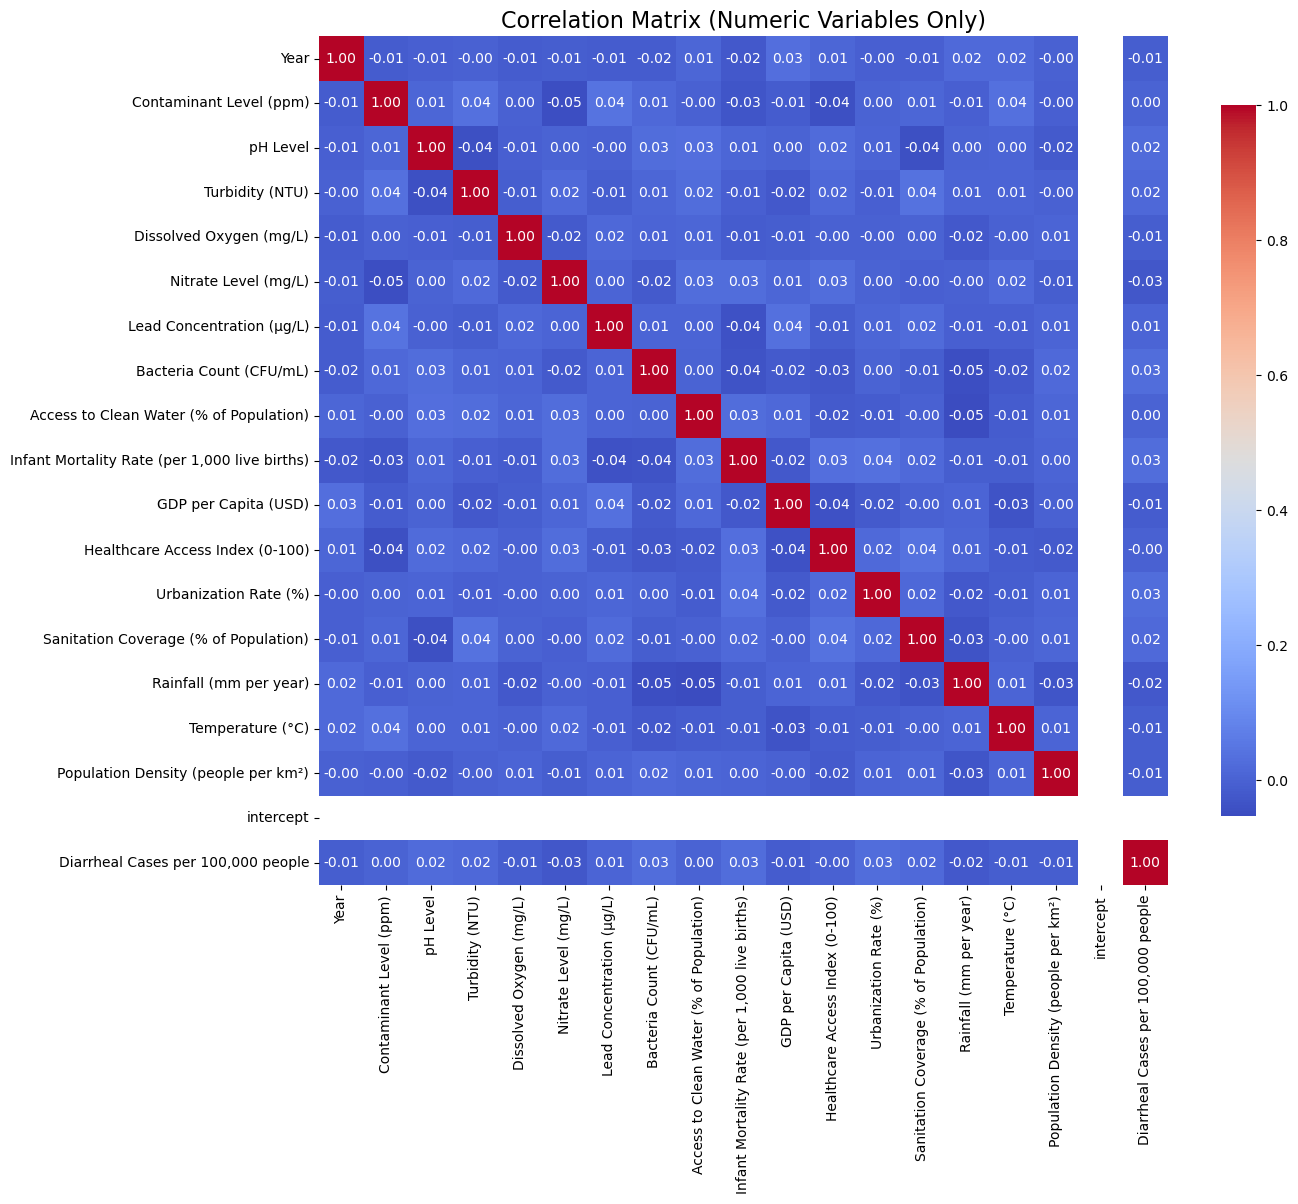

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 12))
sns.heatmap(Train.select_dtypes(include='number').corr(), 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            square=True,
            cbar_kws={"shrink": .8})

plt.title("Correlation Matrix (Numeric Variables Only)", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
lr_model = sm.OLS(y_train, X_train[["Country","Region","Year","Water Source Type","Contaminant Level (ppm)","pH Level","Turbidity (NTU)","Dissolved Oxygen (mg/L)","Nitrate Level (mg/L)","Lead Concentration (µg/L)","Bacteria Count (CFU/mL)","Water Treatment Method","Access to Clean Water (% of Population)","Infant Mortality Rate (per 1,000 live births)","GDP per Capita (USD)","Healthcare Access Index (0-100)","Urbanization Rate (%)","Sanitation Coverage (% of Population)","Rainfall (mm per year)","Temperature (°C)","Population Density (people per km²)"]])
results_lr = lr_model.fit()
print(summarize(results_lr))

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).